In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('neo_data.csv')

df.rename(columns={' Hazardous': 'Hazardous'},inplace=True)
df['Hazardous']=df['Hazardous'].astype(int)

columns_to_drop=[
    'ID', 'Neo Reference ID', 'Name', 'Limited Name', 'Designation', 'NASA JPL URL', 
    'Close Approach Date', 'Close Approach Date (Full)', 'Epoch Date Close Approach', 'Orbiting Body',
    'Min Diameter (m)', 'Max Diameter (m)', 'Min Diameter (miles)', 'Max Diameter (miles)', 
    'Min Diameter (feet)', 'Max Diameter (feet)',
    'Relative Velocity (km/h)', 'Relative Velocity (miles/h)',
    'Miss Distance (lunar)', 'Miss Distance (km)', 'Miss Distance (miles)'
]
df=df.drop(columns=[col for col in columns_to_drop if col in df.columns],errors='ignore')
df=df.dropna()
numerical_features=[
    'Absolute Magnitude (H)','Min Diameter (km)', 'Max Diameter (km)', 
    'Relative Velocity (km/s)', 'Miss Distance (astronomical)'
]
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

display(df.head())


,Absolute Magnitude (H),Min Diameter (km),Max Diameter (km),Hazardous,Relative Velocity (km/s),Miss Distance (astronomical)
0,-2.809691,3.129364,3.129364,0,-1.469400,-0.028916
1,-2.809691,3.129364,3.129364,0,-1.611086,0.523001
2,-2.809691,3.129364,3.129364,0,-1.560557,0.620906
3,-2.809691,3.129364,3.129364,0,-1.586968,0.129222
4,-2.809691,3.129364,3.129364,0,-1.428455,-0.525483


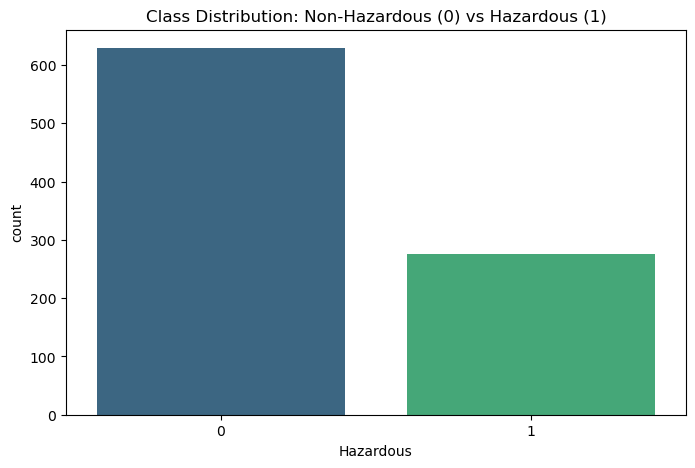

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Hazardous', hue='Hazardous', palette='viridis', legend=False)
plt.title("Class Distribution: Non-Hazardous (0) vs Hazardous (1)")
plt. show()

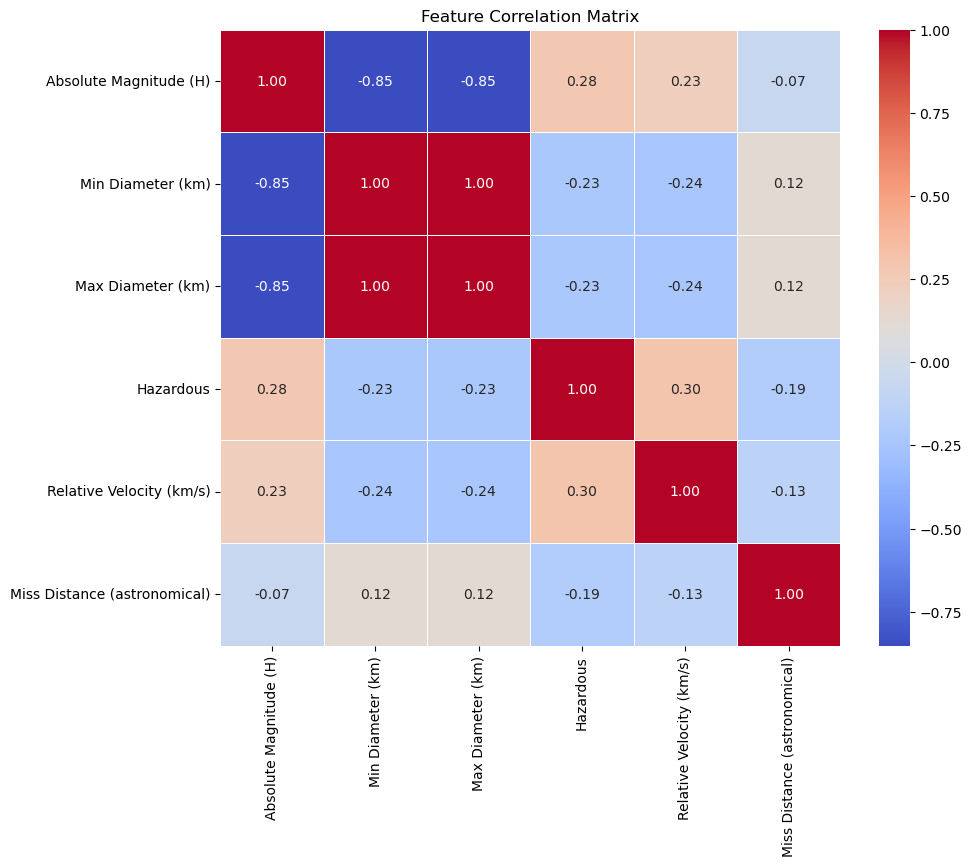

In [19]:
plt.figure(figsize=(10,8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix,annot=True, cmap="coolwarm",fmt=".2f", linewidth=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

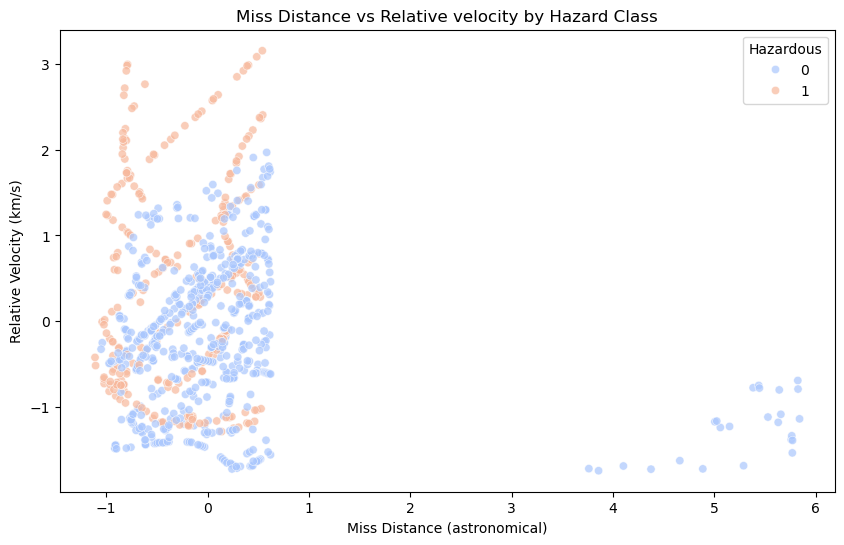

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Miss Distance (astronomical)",
    y="Relative Velocity (km/s)",
    hue="Hazardous",
    alpha=0.7,
    palette="coolwarm"
)
plt.title("Miss Distance vs Relative velocity by Hazard Class")
plt.show()


In [26]:
df= df.drop(columns =['Max Diameter (km)'], errors='ignore')

X=df.drop(columns=['Hazardous'])
y=df['Hazardous']


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       126
           1       1.00      1.00      1.00        55

    accuracy                           1.00       181
   macro avg       1.00      1.00      1.00       181
weighted avg       1.00      1.00      1.00       181



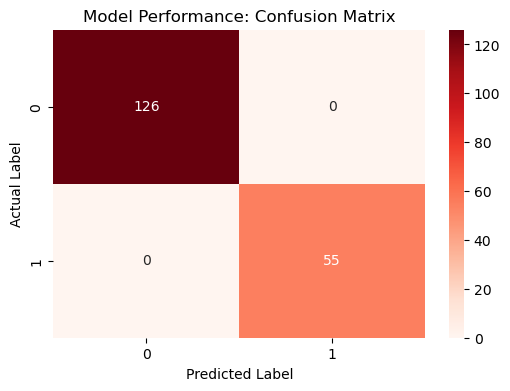

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Model Performance: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

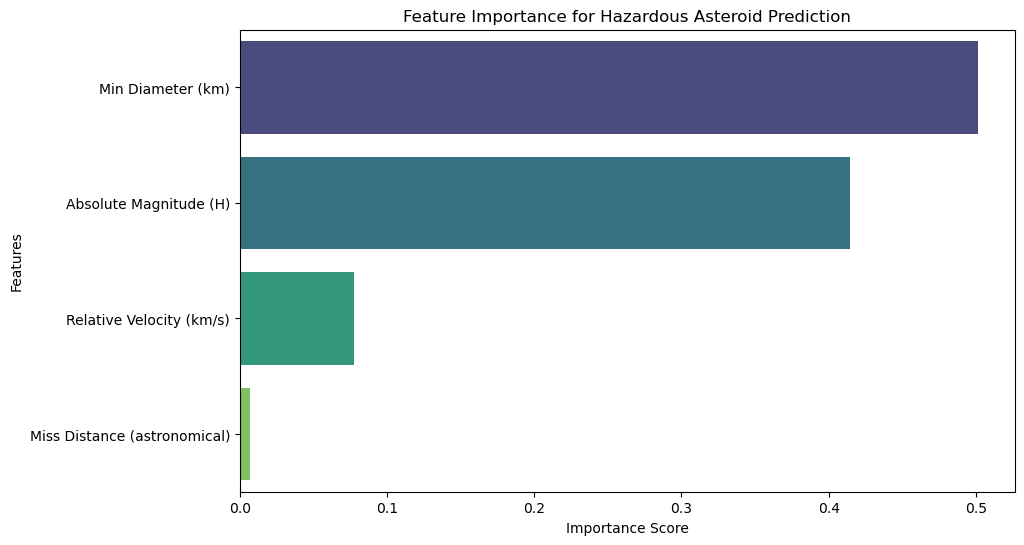

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, hue=feature_importances.index,palette='viridis',legend=False)
plt.title('Feature Importance for Hazardous Asteroid Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [36]:
import joblib
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# Save the model and scaler
joblib.dump(rf_model, 'hazardous_asteroid_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

style = {'description_width': 'initial'}

# Define UI Components
mag_input = widgets.FloatText(description='Absolute Magnitude (H):', style=style)
dia_input = widgets.FloatText(description='Min Diameter (km):', style=style)
vel_input = widgets.FloatText(description='Relative Velocity (km/s):', style=style)
dist_input = widgets.FloatText(description='Miss Distance (astronomical):', style=style)

button = widgets.Button(description="Predict Hazard", button_style='danger')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        
        # 1. Create input data containing a dummy column to satisfy the Phase 1 Scaler
        input_data_scaler = pd.DataFrame({
            'Absolute Magnitude (H)': [mag_input.value],
            'Min Diameter (km)': [dia_input.value],
            'Max Diameter (km)': [0.0], # Dummy value
            'Relative Velocity (km/s)': [vel_input.value],
            'Miss Distance (astronomical)': [dist_input.value]
        })
        
        # 2. Transform the data
        input_scaled = scaler.transform(input_data_scaler)
        
        # 3. Reconstruct a DataFrame to isolate the scaled columns
        scaled_columns = [
            'Absolute Magnitude (H)', 'Min Diameter (km)', 
            'Max Diameter (km)', 'Relative Velocity (km/s)', 
            'Miss Distance (astronomical)'
        ]
        input_scaled_df = pd.DataFrame(input_scaled, columns=scaled_columns)
        
        # 4. Drop the dummy column so the shape matches the Phase 4 Random Forest model
        input_final = input_scaled_df.drop(columns=['Max Diameter (km)'])
        
        # 5. Execute Prediction
        prediction = rf_model.predict(input_final)
        
        if prediction[0] == 1:
            print("Prediction: HAZARDOUS")
        else:
            print("Prediction: NON-HAZARDOUS")

button.on_click(on_button_clicked)

ui = widgets.VBox([mag_input, dia_input, vel_input, dist_input, button, output])
display(ui)